# Understanding and writing algorithms

`cfsPOPCON` is a library for running many simple interdependent calculations which have physically-meaningful inputs and outputs.

Although the example cases run through a pre-defined set of calculations, we wanted to allow users to change the order of the calculations, switch calculations on and off, and let users decide whether they want variables to be calculated or set as inputs.

To make this easier to do, we developed the `Algorithm` class. This has a fairly complicated implementation (see `cfspopcon/algorithm_class.py`), but it is straightforward to use.

In this notebook, we'll discuss what the `Algorithm` class is doing, and how to implement your own algorithms.

In [1]:
%reload_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cfspopcon
from cfspopcon.unit_handling import Quantity, ureg, wraps_ufunc
from cfspopcon.algorithm_class import Algorithm, CompositeAlgorithm
from cfspopcon.formulas.energy_confinement.read_energy_confinement_scalings import ConfinementScaling

# Change to the top-level directory. Required to find radas_dir in its default location.
%cd {Path(cfspopcon.__file__).parents[1]}
# As a sanity check, print out the current working directory
print(f"Running in {Path('').absolute()}")

/mnt/home/audreysa/cfspopcon
Running in /mnt/home/audreysa/cfspopcon


In [2]:
input_parameters, algorithm_original, points, plots  = cfspopcon.read_case("example_cases/SPARC_PRD")

In [3]:
algorithm_original.algorithms

[Algorithm: read_atomic_data,
 Algorithm: set_up_impurity_concentration_array,
 Algorithm: calc_separatrix_elongation_from_areal_elongation,
 Algorithm: calc_separatrix_triangularity_from_triangularity95,
 Algorithm: calc_minor_radius_from_inverse_aspect_ratio,
 Algorithm: calc_vertical_minor_radius_from_elongation_and_minor_radius,
 Algorithm: calc_plasma_volume,
 Algorithm: calc_plasma_surface_area,
 Algorithm: calc_f_shaping_for_qstar,
 Algorithm: calc_q_star_from_plasma_current,
 Algorithm: calc_average_ion_mass,
 Algorithm: calc_average_ion_temp_from_temperature_ratio,
 Algorithm: calc_zeff_and_dilution_due_to_impurities,
 Algorithm: calc_plasma_stored_energy,
 Algorithm: read_confinement_scalings,
 Algorithm: solve_energy_confinement_scaling_for_input_power,
 Algorithm: calc_beta_toroidal,
 Algorithm: calc_beta_poloidal,
 Algorithm: calc_beta_total,
 Algorithm: calc_beta_normalized,
 Algorithm: calc_peaked_profiles,
 Algorithm: calc_intrinsic_radiated_power_from_core,
 Algorithm:

In [4]:

ds = xr.Dataset(input_parameters)
ds = algorithm_original.update_dataset(ds)
ds_copy = ds.copy()


In [5]:
ds['average_electron_temp'].shape

(30,)

In [6]:
# ds['average_electron_temp']
P_auxes = (np.ones((40,1)) * np.linspace(0,25,30) * ureg.MW )
ds['P_auxillary_launched'].dims
ds['P_auxillary_launched'] = xr.DataArray(P_auxes, dims=['dim_average_electron_density', 'dim_average_electron_temp'])

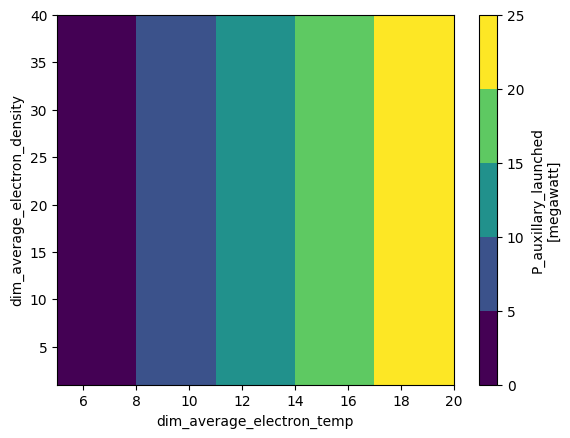

In [7]:
ds['P_auxillary_launched'].plot.contourf()

In [8]:
ds['P_in']= ds['P_auxillary_launched'] + ds['P_ohmic'] + ds['P_alpha']

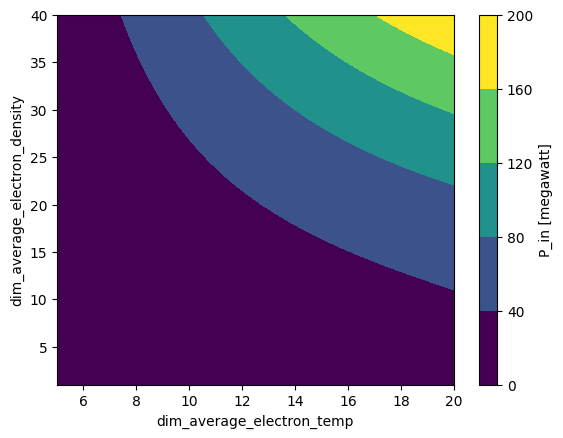

In [9]:
ds['P_in'].plot.contourf()

In [14]:


@Algorithm.register_algorithm(return_keys=["energy_confinement_time"])
@wraps_ufunc(
    return_units=dict(tau_e=ureg.s),
    input_units=dict(
        confinement_time_scalar=ureg.dimensionless,
        plasma_current=ureg.MA,
        magnetic_field_on_axis=ureg.T,
        average_electron_density=ureg.n19,
        major_radius=ureg.m,
        areal_elongation=ureg.dimensionless,
        separatrix_elongation=ureg.dimensionless,
        inverse_aspect_ratio=ureg.dimensionless,
        average_ion_mass=ureg.amu,
        triangularity_psi95=ureg.dimensionless,
        separatrix_triangularity=ureg.dimensionless,
        P_in = ureg.MW,
        q_star=ureg.dimensionless,
        energy_confinement_scaling=None,
    ),
    output_core_dims=[()],
)
def calc_energy_confinement_time_from_P_in(
    confinement_time_scalar: float,
    plasma_current: float,
    magnetic_field_on_axis: float,
    average_electron_density: float,
    major_radius: float,
    areal_elongation: float,
    separatrix_elongation: float,
    inverse_aspect_ratio: float,
    average_ion_mass: float,
    triangularity_psi95: float,
    separatrix_triangularity: float,
    P_in: float,
    q_star: float,
    energy_confinement_scaling: str,
) -> float:
    r"""Calculate the energy confinement time from the input power.

    Args:
        confinement_time_scalar: [~] confinement scaling factor
        plasma_current: [MA] :term:`glossary link<plasma_current>`
        magnetic_field_on_axis: [T] :term:`glossary link<magnetic_field_on_axis>`
        average_electron_density: [1e19 m^-3] :term:`glossary link<average_electron_density>`
        major_radius: [m] :term:`glossary link<major_radius>`
        areal_elongation: [~] :term:`glossary link<areal_elongation>`
        separatrix_elongation: [~] :term:`glossary link<separatrix_elongation>`
        inverse_aspect_ratio: [~] :term:`glossary link<inverse_aspect_ratio>`
        average_ion_mass: [amu] :term:`glossary link<average_ion_mass>`
        triangularity_psi95: [~] :term:`glossary link<triangularity_psi95>`
        separatrix_triangularity: [~] :term:`glossary link<separatrix_triangularity>`
        P_in: [MW] :term:`glossary link<P_in>`
        q_star: [~] :term:`glossary link<q_star>`
        energy_confinement_scaling: [] :term:`glossary link<energy_confinement_scaling>`

    Returns:
        :term:`energy_confinement_time` [s], 
    """
    scaling = ConfinementScaling.instances[energy_confinement_scaling]

    energy_confinement_time = (
        confinement_time_scalar
        * scaling.constant
        * plasma_current**scaling.plasma_current_alpha
        * magnetic_field_on_axis**scaling.field_on_axis_alpha
        * average_electron_density**scaling.average_density_alpha
        * major_radius**scaling.major_radius_alpha
        * areal_elongation**scaling.areal_elongation_alpha
        * separatrix_elongation**scaling.separatrix_elongation_alpha
        * inverse_aspect_ratio**scaling.inverse_aspect_ratio_alpha
        * average_ion_mass**scaling.mass_ratio_alpha
        * P_in**scaling.input_power_alpha
        * (1.0 + np.mean([triangularity_psi95, separatrix_triangularity])) ** scaling.triangularity_alpha
        * q_star**scaling.qstar_alpha
    )

    return energy_confinement_time


In [15]:
algorithm2 = Algorithm.get_algorithm("calc_energy_confinement_time_from_P_in")
ds = algorithm2.update_dataset(ds)

#### Compare the original energy confinement time consistent with the stored energy at each average_electron_temp with the energy_confinement_time enforcing P_in

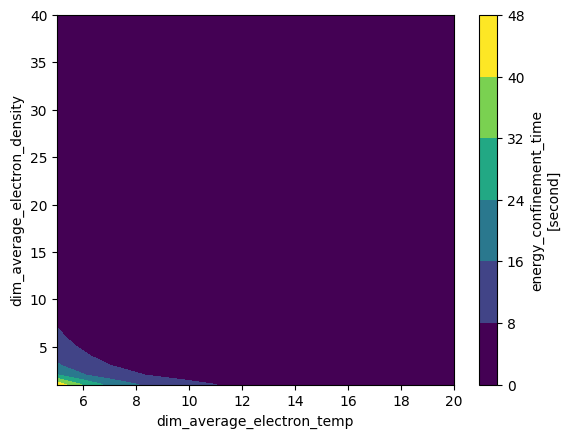

In [18]:
ds_copy['energy_confinement_time'].plot.contourf()

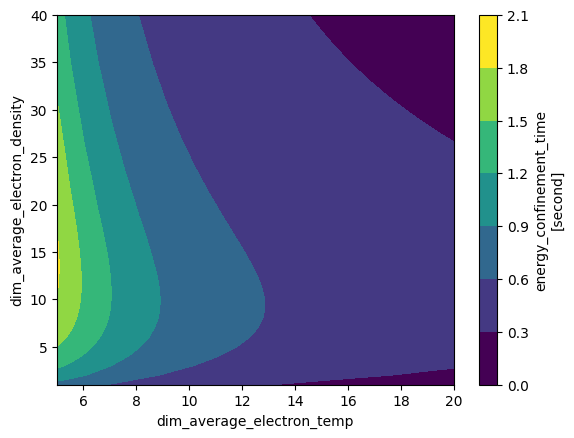

In [16]:
ds['energy_confinement_time'].plot.contourf()

#### Calculate the stored energy consistent with our enforced Pin and energy_confinement_time

In [27]:
ds['plasma_stored_energy'] = ds['energy_confinement_time'] * ds['P_in']
ds['plasmas_stored_energy'] = ds['plasma_stored_energy'].pint.to(ureg.MJ)

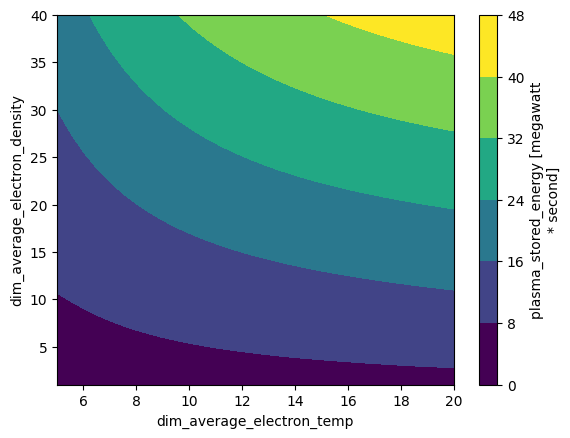

In [28]:
ds['plasma_stored_energy'].plot.contourf()

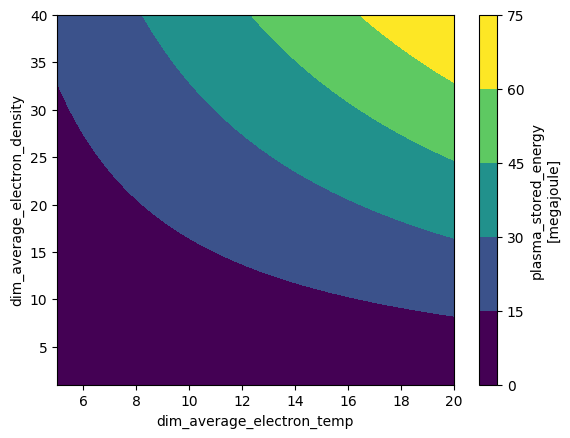

In [24]:
ds_copy['plasma_stored_energy'].plot.contourf()

#### Now, we will calculate the average_electron_temperature consistent with this plasma_stored_energy

In [31]:
summed_impurity_concentration = ds['impurity_concentration'].sum(dim="dim_species")
denominator = 3 * ds['plasma_volume'] * (1 + (ds['dilution'] + summed_impurity_concentration) * ds['ion_to_electron_temp_ratio']) * ds['average_electron_density'] 
denominator = denominator.pint.to(ureg.dimensionless)

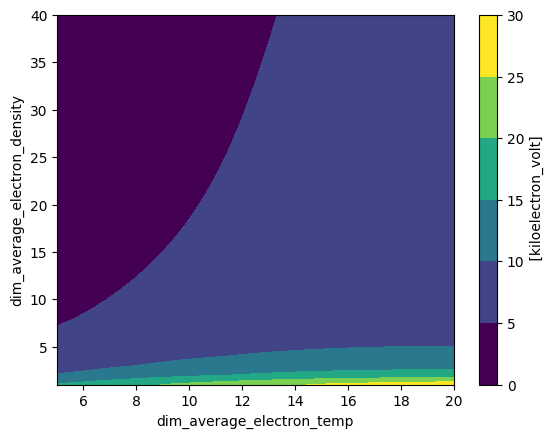

In [37]:
average_electron_temp = ds['plasma_stored_energy'] / denominator
average_electron_temp = average_electron_temp.pint.to(ureg.keV)
average_electron_temp.plot.contourf()

In [41]:
ds['average_electron_temp'] = average_electron_temp
ds['average_electron_temp'].plot.contourf()

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

In [ ]:
algorithm = Algorithm.get_algorithm('calc_peaked_profiles')
ds = algorithm.update_dataset(ds)


In [ ]:
ds = algorithm.update_dataset(ds)
